# MULTIPLE LINEAR REGRESSION

**1. Exploratory Data Analysis (EDA) and Preprocessing**

In [ ]:
##importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso

In [ ]:
##Loading the Dataset

df=pd.read_csv('ToyotaCorolla - MLR.csv')

In [ ]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [ ]:
##Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [ ]:
##Summary Statistics

df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [ ]:
##checking missing values

df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [ ]:
##checking duplicated

df.duplicated().sum()

np.int64(1)

In [ ]:
##removing duplicates

df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

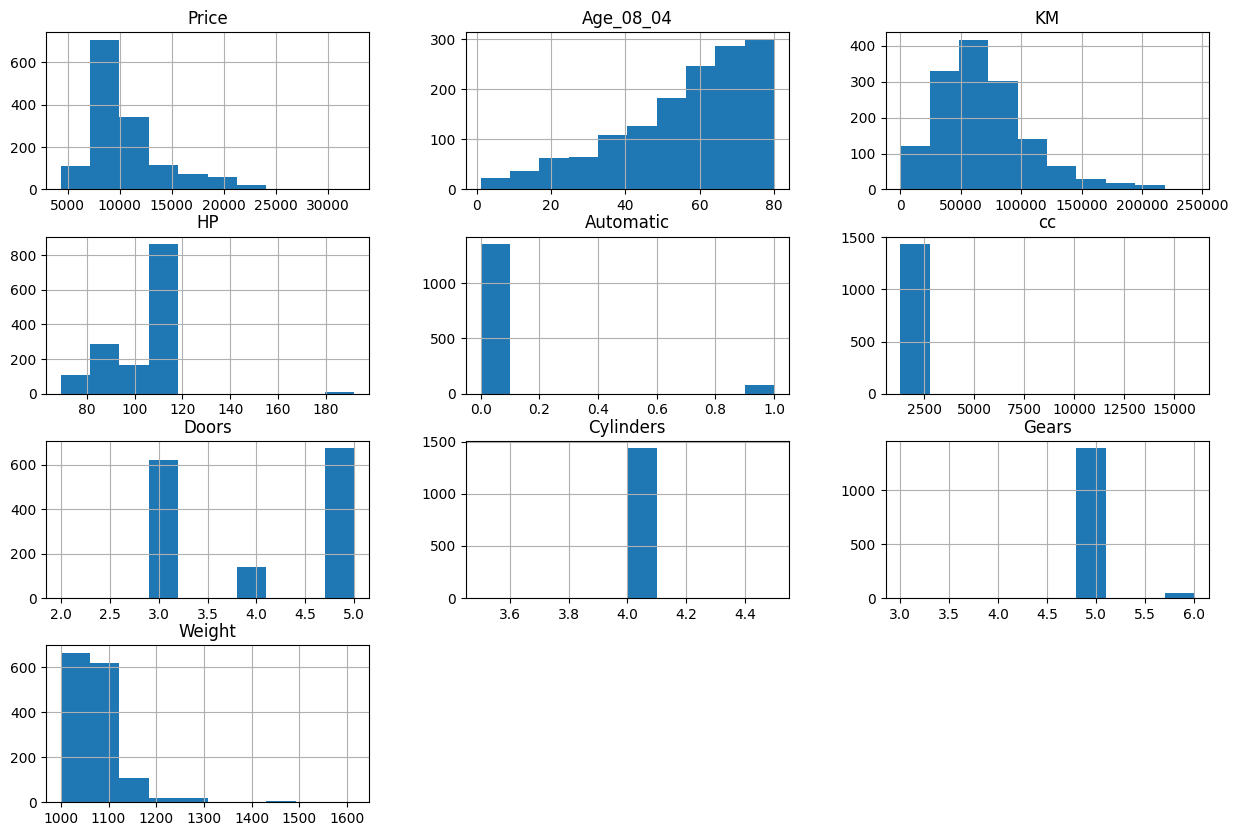

In [ ]:
##Histogram

df.hist(figsize=(15,10))
plt.show()

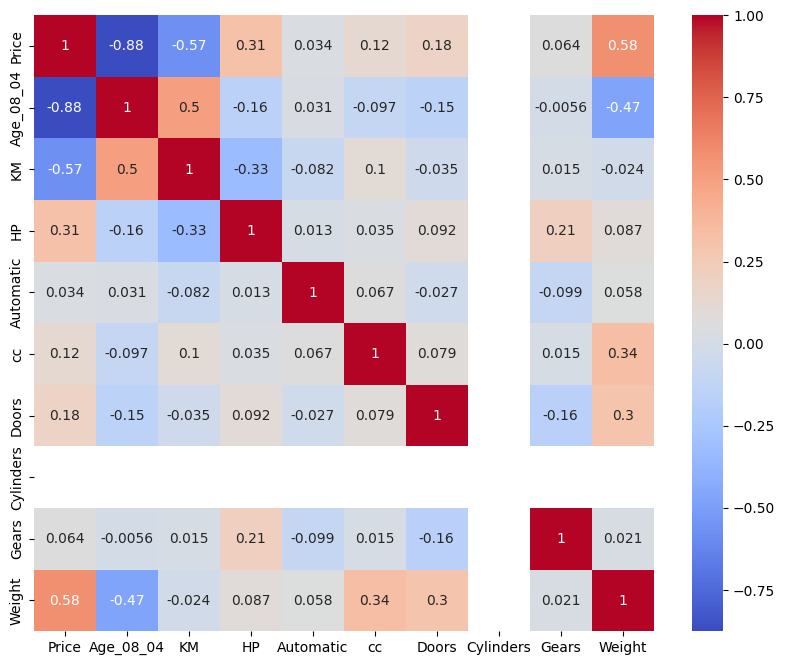

In [ ]:
##Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
##Encoding FuelType

if 'Fuel_Type' in df.columns:
    df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)
else:
    print("Column 'Fuel_Type' not found in DataFrame. It might have already been encoded.")

**2. Split the Dataset into Training and Testing Sets**

In [ ]:
##defining features and target

X = df.drop('Price', axis=1)
y = df['Price']

In [ ]:
#spliting dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

**3. Build Multiple Linear Regression Models**

In [ ]:
##model 1

X1 = df[['Age_08_04','KM','HP','Weight']]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y, test_size=0.20, random_state=42
)

model1 = LinearRegression()
model1.fit(X1_train, y1_train)

print(model1.coef_)

[-1.20619071e+02 -2.00736433e-02  3.14785892e+01  1.98479994e+01]


In [ ]:
##model 2

X2 = df[['Age_08_04','KM','HP','cc','Weight']]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.20, random_state=42
)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

print(model2.coef_)

[-1.20550340e+02 -1.99269271e-02  3.16464196e+01 -1.19686021e-01
  2.02223444e+01]


In [ ]:
##model 3

X3 = df[['Age_08_04','KM','HP','cc','Weight']]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y, test_size=0.20, random_state=42
)

model3 = LinearRegression()
model3.fit(X3_train, y3_train)

print(model3.coef_)

[-1.20550340e+02 -1.99269271e-02  3.16464196e+01 -1.19686021e-01
  2.02223444e+01]


In [ ]:
coef_table = pd.DataFrame({
    'Feature': X3.columns,
    'Coefficient': model3.coef_
})

print(coef_table)

     Feature  Coefficient
0  Age_08_04  -120.550340
1         KM    -0.019927
2         HP    31.646420
3         cc    -0.119686
4     Weight    20.222344


**4. Evaluate Model Performance**

In [ ]:
##evaluating model1

pred1 = model1.predict(X1_test)

print("MAE:", mean_absolute_error(y1_test, pred1))
print("MSE:", mean_squared_error(y1_test, pred1))
print("RMSE:", np.sqrt(mean_squared_error(y1_test, pred1)))
print("R2 Score:", r2_score(y1_test, pred1))

MAE: 987.225283393743
MSE: 1934478.8193824282
RMSE: 1390.8554272038587
R2 Score: 0.8387549179514566


In [ ]:
##evaluating model2
pred2 = model2.predict(X2_test)

print("MAE:", mean_absolute_error(y2_test, pred2))
print("MSE:", mean_squared_error(y2_test, pred2))
print("RMSE:", np.sqrt(mean_squared_error(y2_test, pred2)))
print("R2 Score:", r2_score(y2_test, pred2))

MAE: 985.5830249160908
MSE: 1941828.2085079267
RMSE: 1393.494961780604
R2 Score: 0.8381423225378113


In [ ]:
##evaluating model3
pred3 = model3.predict(X3_test)

print("MAE:", mean_absolute_error(y3_test, pred3))
print("MSE:", mean_squared_error(y3_test, pred3))
print("RMSE:", np.sqrt(mean_squared_error(y3_test, pred3)))
print("R2 Score:", r2_score(y3_test, pred3))

MAE: 985.5830249160908
MSE: 1941828.2085079267
RMSE: 1393.494961780604
R2 Score: 0.8381423225378113


**5. Apply Ridge and Lasso Methods**

In [ ]:
##Ridge method

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("R2 Score:", r2_score(y_test, ridge_pred))

R2 Score: 0.8205816343653275


In [ ]:
##Lasso method

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("R2 Score:", r2_score(y_test, lasso_pred))

R2 Score: 0.8210480708679172


*Conclusion : Multiple Linear Regression, Ridge Regression, and Lasso Regression were used to predict Toyota Corolla prices. The models were evaluated using MAE, MSE, RMSE, and R² score, and the best-performing model can be selected based on these metrics.*

# Interview Questions

**1. What is Normalization and Standardization? How is it Helpful?**

*Normalization is a method used to scale data values into a fixed range, usually between 0 and 1.

*Standardization is a method used to transform data so that all features have a similar scale around the average value.

Normalization and standardization help machine learning models perform better by ensuring that all features are treated fairly. They prevent features with larger values from having a greater influence on the model and can improve both accuracy and training speed.

**2. What Techniques Can Be Used to Address Multicollinearity in Multiple Linear Regression?**

Multicollinearity occurs when two or more independent variables are highly related to each other. This can make the model unstable and difficult to interpret.

Some common ways to handle it are:

Removing highly correlated variables.
Selecting only the most important features.
Using VIF (Variance Inflation Factor) to identify problematic variables.
Applying Ridge Regression or Lasso Regression.
Using PCA to reduce the number of correlated features.